name: Kartikey Attri


roll.no: 8025320046

Lab Assignment 3  

In [14]:
# Q1 — E-Commerce Sales Data Analysis
# Part I: Randomized Sales Data Generation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Initialize Random Seed (replace with your roll number) ──────────────
roll_number = 46  # 🔁 Replace with YOUR roll number
np.random.seed(roll_number)

# ── 2. Generate Sales Data ─────────────────────────────────────────────────
# Shape: (12 months x 4 categories), values between 1000 and 5000
low  = 1000 + (roll_number % 500)   # randomized lower bound using seed
high = 5000 - (roll_number % 300)   # randomized upper bound using seed

sales_data = np.random.randint(low, high, size=(12, 4))
print("Raw Sales Data (NumPy Array):\n", sales_data)
print("Shape:", sales_data.shape)

# ── 3. Convert to DataFrame ────────────────────────────────────────────────
months     = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]
categories = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

df = pd.DataFrame(sales_data, index=months, columns=categories)
print("\nDataFrame:\n", df)

Raw Sales Data (NumPy Array):
 [[4307 3931 2622 4490]
 [3536 3497 1704 4833]
 [2386 3505 4070 3841]
 [3736 4190 1590 3893]
 [1869 1836 1656 4177]
 [1381 2868 4472 1688]
 [3720 4780 4845 4062]
 [1678 1932 4114 4806]
 [3864 2049 4737 2314]
 [2238 3294 4322 3991]
 [1458 1751 2318 1126]
 [3186 3537 3629 2187]]
Shape: (12, 4)

DataFrame:
      Electronics  Clothing  Home & Kitchen  Sports
Jan         4307      3931            2622    4490
Feb         3536      3497            1704    4833
Mar         2386      3505            4070    3841
Apr         3736      4190            1590    3893
May         1869      1836            1656    4177
Jun         1381      2868            4472    1688
Jul         3720      4780            4845    4062
Aug         1678      1932            4114    4806
Sep         3864      2049            4737    2314
Oct         2238      3294            4322    3991
Nov         1458      1751            2318    1126
Dec         3186      3537            3629    2187


In [23]:
# Part II: Data Manipulation and Analysis
# ── 1. First 5 rows & Summary Statistics ──────────────────────────────────
print("First 5 Rows:\n", df.head())
print("\nSummary Statistics:\n", df.describe())

# ── 2. Total Sales per Category & per Month ────────────────────────────────
total_per_category = df.sum(axis=0)
total_per_month    = df.sum(axis=1)

print("\nTotal Sales per Category:\n", total_per_category)
print("\nTotal Sales per Month:\n", total_per_month)

# ── 3. Average Sales Growth Between Consecutive Months ────────────────────
monthly_diff   = df.diff().dropna()                   # absolute change
avg_growth     = monthly_diff.mean()
print("\nAverage Monthly Sales Growth per Category:\n", avg_growth)

# ── 4. Add Total Sales & Growth Rate Columns ──────────────────────────────
df["Total Sales"] = df[categories].sum(axis=1)
df["Growth Rate"] = df["Total Sales"].pct_change() * 100   # percentage change
df["Growth Rate"] = df["Growth Rate"].round(2)

print("\nDataFrame with Total Sales & Growth Rate:\n", df)

# ── 5. Apply Randomized Discount Based on Roll Number ─────────────────────
if roll_number % 2 == 0:
    df["Electronics"] = (df["Electronics"] * 0.90).round(2)   # 10% discount
    print(f"\nRoll {roll_number} is EVEN → 10% discount applied to Electronics")
else:
    df["Clothing"] = (df["Clothing"] * 0.85).round(2)         # 15% discount
    print(f"\nRoll {roll_number} is ODD → 15% discount applied to Clothing")

print("\nFinal DataFrame after Discount:\n", df)

First 5 Rows:
      Electronics  Clothing  Home & Kitchen  Sports
Jan         4307      3931            2622    4490
Feb         3536      3497            1704    4833
Mar         2386      3505            4070    3841
Apr         3736      4190            1590    3893
May         1869      1836            1656    4177

Summary Statistics:
        Electronics     Clothing  Home & Kitchen       Sports
count    12.000000    12.000000       12.000000    12.000000
mean   2779.916667  3097.500000     3339.916667  3450.666667
std    1054.811613  1008.661174     1272.532869  1270.976313
min    1381.000000  1751.000000     1590.000000  1126.000000
25%    1821.250000  2019.750000     2164.500000  2282.250000
50%    2786.000000  3395.500000     3849.500000  3942.000000
75%    3724.000000  3635.500000     4359.500000  4255.250000
max    4307.000000  4780.000000     4845.000000  4833.000000

Total Sales per Category:
 Electronics       33359
Clothing          37170
Home & Kitchen    40079
Sports  

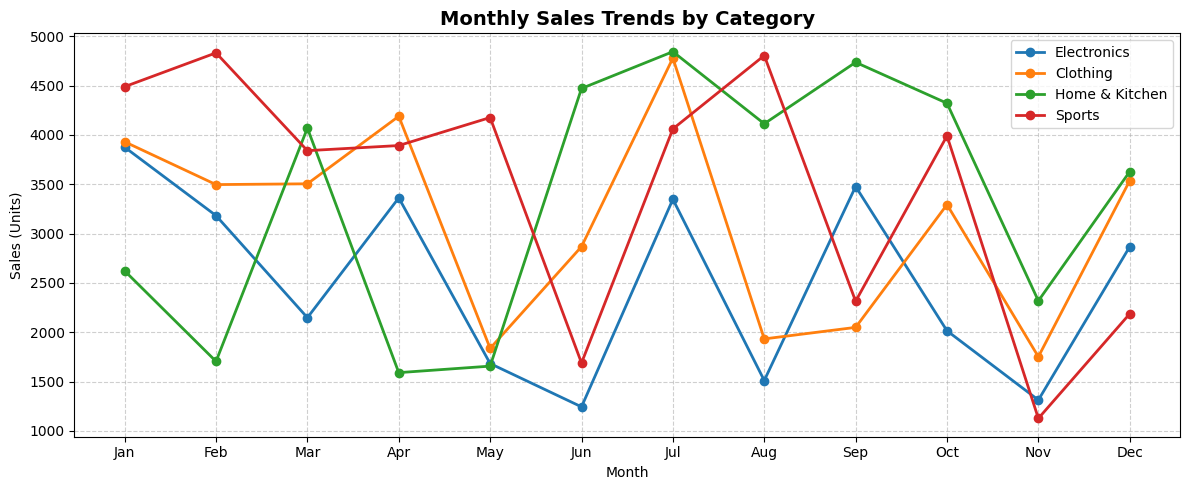

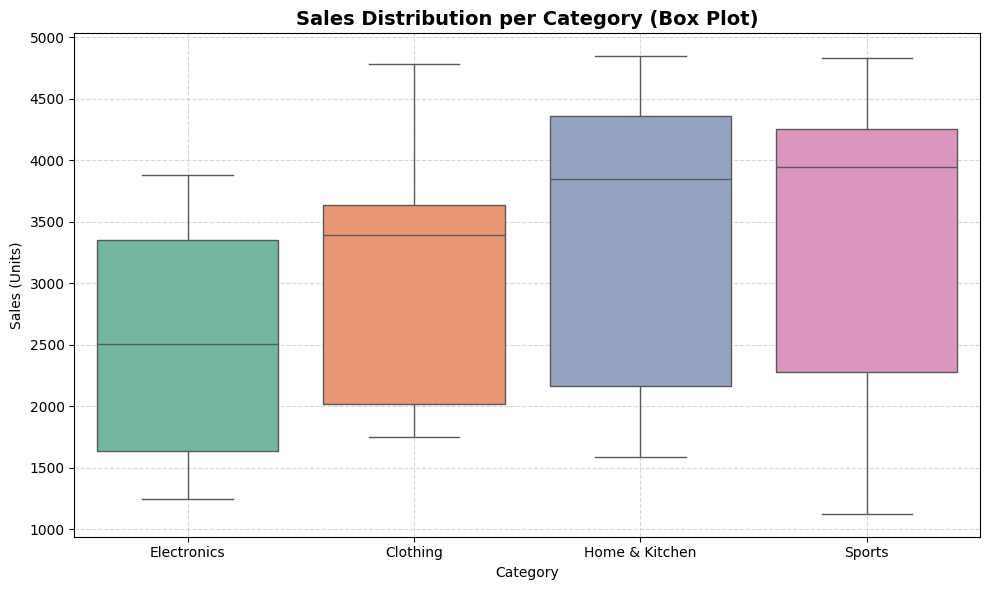

In [25]:
# Part III: Visualizations
# ── 1. Line Plot — Monthly Sales Trends ───────────────────────────────────
plt.figure(figsize=(12, 5))
for col in categories:
    plt.plot(months, df[col], marker='o', label=col, linewidth=2)

plt.title("Monthly Sales Trends by Category", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales (Units)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("sales_trends.png", dpi=150)
plt.show()

# ── 2. Box Plot — Sales Distribution per Category ─────────────────────────
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[categories], palette="Set2")

plt.title("Sales Distribution per Category (Box Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Sales (Units)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("sales_boxplot.png", dpi=150)
plt.show()

In [15]:
# Q2 — NumPy Array Operations
import numpy as np

array = np.array([[1, -2, 3],
                  [-4, 5, -6]])

# ── i. Element-wise Absolute Value ────────────────────────────────────────
print("Original Array:\n", array)
print("\ni. Absolute Values:\n", np.abs(array))

# ── ii. Percentiles ───────────────────────────────────────────────────────
percentiles = [25, 50, 75]

print("\nii. Percentiles:")
print("  Flattened array →", np.percentile(array, percentiles))

print("  Per Column (axis=0):")
for p in percentiles:
    print(f"    {p}th percentile: {np.percentile(array, p, axis=0)}")

print("  Per Row (axis=1):")
for p in percentiles:
    print(f"    {p}th percentile: {np.percentile(array, p, axis=1)}")

# ── iii. Mean, Median, Standard Deviation ─────────────────────────────────
print("\niii. Statistical Measures:")
print("  -- Flattened --")
print(f"  Mean   : {np.mean(array):.4f}")
print(f"  Median : {np.median(array):.4f}")
print(f"  Std Dev: {np.std(array):.4f}")

print("\n  -- Per Column (axis=0) --")
print(f"  Mean   : {np.mean(array, axis=0)}")
print(f"  Median : {np.median(array, axis=0)}")
print(f"  Std Dev: {np.std(array, axis=0)}")

print("\n  -- Per Row (axis=1) --")
print(f"  Mean   : {np.mean(array, axis=1)}")
print(f"  Median : {np.median(array, axis=1)}")
print(f"  Std Dev: {np.std(array, axis=1)}")

Original Array:
 [[ 1 -2  3]
 [-4  5 -6]]

i. Absolute Values:
 [[1 2 3]
 [4 5 6]]

ii. Percentiles:
  Flattened array → [-3.5 -0.5  2.5]
  Per Column (axis=0):
    25th percentile: [-2.75 -0.25 -3.75]
    50th percentile: [-1.5  1.5 -1.5]
    75th percentile: [-0.25  3.25  0.75]
  Per Row (axis=1):
    25th percentile: [-0.5 -5. ]
    50th percentile: [ 1. -4.]
    75th percentile: [2.  0.5]

iii. Statistical Measures:
  -- Flattened --
  Mean   : -0.5000
  Median : -0.5000
  Std Dev: 3.8622

  -- Per Column (axis=0) --
  Mean   : [-1.5  1.5 -1.5]
  Median : [-1.5  1.5 -1.5]
  Std Dev: [2.5 3.5 4.5]

  -- Per Row (axis=1) --
  Mean   : [ 0.66666667 -1.66666667]
  Median : [ 1. -4.]
  Std Dev: [2.05480467 4.78423336]


In [18]:
# Q3 — Floor, Ceiling, Truncate, Round
import numpy as np

a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Original Array :", a)
print("Floor values   :", np.floor(a))      # rounds DOWN to nearest integer
print("Ceiling values :", np.ceil(a))       # rounds UP  to nearest integer
print("Truncated values:", np.trunc(a))     # drops decimal (towards zero)
print("Rounded values :", np.round(a))      # standard rounding (nearest even)


Original Array : [-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]
Floor values   : [-2. -2. -1.  0.  1.  1.  3.]
Ceiling values : [-1. -1. -0.  1.  2.  2.  3.]
Truncated values: [-1. -1. -0.  0.  1.  1.  3.]
Rounded values : [-2. -2. -0.  0.  2.  2.  3.]


In [19]:
# Q4 — Swap Two Elements in a List Using a Temporary Variable
# Swap elements at index i and j using a temp variable

my_list = [10, 20, 30, 40, 50]
print("Original List:", my_list)

i, j = 1, 4    # indices to swap (swap 20 and 50)

# Using a temporary variable
temp       = my_list[i]
my_list[i] = my_list[j]
my_list[j] = temp

print(f"After swapping index {i} and {j}:", my_list)

Original List: [10, 20, 30, 40, 50]
After swapping index 1 and 4: [10, 50, 30, 40, 20]


In [21]:
# Q5 — Swap Two Elements in a Set (via List Conversion)
# Sets are unordered — convert to list, swap, convert back

my_set = {10, 20, 30, 40, 50}
print("Original Set:", my_set)

# Convert set → list (to get indexed access)
temp_list = list(my_set)
print("Set as List :", temp_list)

i, j = 0, 2    # indices to swap

# Swap using temp variable
temp          = temp_list[i]
temp_list[i]  = temp_list[j]
temp_list[j]  = temp

print(f"After swapping index {i} and {j} in list:", temp_list)

# Convert back to set
swapped_set = set(temp_list)
print("Back to Set :", swapped_set)

Original Set: {50, 20, 40, 10, 30}
Set as List : [50, 20, 40, 10, 30]
After swapping index 0 and 2 in list: [40, 20, 50, 10, 30]
Back to Set : {40, 10, 50, 20, 30}
